# Lasso 

과적합(Overfitting)을 방지하기 위한 규제(Regularization) 기법  
OLS(최소자승법)가 "오직 오차를 줄이는 것"에만 집착한다면, Lasso는 거기에 "모델을 심플하게 유지하라"는 조건을 추가  
Lasso는 모델의 복잡도를 결정하는 계수(Coefficient, w)의 크기를 억제하여 모델을 더 일반화  
Linear Model trained with L1 prior as regularizer (aka the Lasso).  
  
The optimization objective for Lasso is:  
$ (1 / (2 * n_samples)) * ||y - Xw||^2_2 + \alpha * ||w||_1 $  
  
앞부분: MSE, 뒷부분: L1 Regularization  
모델이 오차를 줄이려고 계수(w)를 키우면 뒷부분의 패널티가 커짐  
  
Lasso의 가장 큰 매력은 중요하지 않은 변수의 계수를 정확히 0으로 만들어 버린다는 점  
이를 통해 복잡한 데이터셋에서 중요한 특징(Feature)만 골라내는 효과  
최적의 알파를 찾아야 함

Lasso regression relies upon the linear regression model but additionaly performs a so called L1 regularization, which is a process of introducing additional information in order to prevent overfitting. As a consequence, we can fit a model containing all possible predictors and use lasso to perform variable selection by using a technique that regularizes the coefficient estimates (it shrinks the coefficient estimates towards zero). In particular, the minimization objective does not only include the residual sum of squares (RSS) - like in the OLS regression setting - but also the sum of the absolute value of coefficients.

$\alpha$ can take various values:

- $\alpha$ = 0: 규제가 전혀 없어 일반 선형 회귀가 됩니다.
- $\alpha$ = ∞: 패널티가 너무 커서 모든 w를 0으로 만듭니다. (모델이 아무것도 안 함)
- 0 < $\alpha$ < ∞: 오차와 계수 크기 사이에서 타협점을 찾습니다. 일부 계수는 0이 됩니다.

In [ ]:
import pandas as pd # 알파 구하는 기준 찾기(hyperparameter), rasso, ridege, elasticnet, penalty

df = pd.read_csv("https://raw.githubusercontent.com/kirenz/datasets/master/Hitters.csv")

In [ ]:
df

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497,127,7,65,48,37,5,2703,806,32,379,311,138,N,E,325,9,3,700.0,N
318,492,136,5,76,50,94,12,5511,1511,39,897,451,875,A,E,313,381,20,875.0,A
319,475,126,3,61,43,52,6,1700,433,7,217,93,146,A,W,37,113,7,385.0,A
320,573,144,9,85,60,78,8,3198,857,97,470,420,332,A,E,1314,131,12,960.0,A


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      322 non-null    int64  
 1   Hits       322 non-null    int64  
 2   HmRun      322 non-null    int64  
 3   Runs       322 non-null    int64  
 4   RBI        322 non-null    int64  
 5   Walks      322 non-null    int64  
 6   Years      322 non-null    int64  
 7   CAtBat     322 non-null    int64  
 8   CHits      322 non-null    int64  
 9   CHmRun     322 non-null    int64  
 10  CRuns      322 non-null    int64  
 11  CRBI       322 non-null    int64  
 12  CWalks     322 non-null    int64  
 13  League     322 non-null    object 
 14  Division   322 non-null    object 
 15  PutOuts    322 non-null    int64  
 16  Assists    322 non-null    int64  
 17  Errors     322 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  322 non-null    object 
dtypes: float64

## Check any missing value

In [4]:
print(df.isnull().sum())

AtBat         0
Hits          0
HmRun         0
Runs          0
RBI           0
Walks         0
Years         0
CAtBat        0
CHits         0
CHmRun        0
CRuns         0
CRBI          0
CWalks        0
League        0
Division      0
PutOuts       0
Assists       0
Errors        0
Salary       59
NewLeague     0
dtype: int64


We take out 59 samples out of 322 records 

In [5]:
df = df.dropna()

In [6]:
df

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,750.0,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497,127,7,65,48,37,5,2703,806,32,379,311,138,N,E,325,9,3,700.0,N
318,492,136,5,76,50,94,12,5511,1511,39,897,451,875,A,E,313,381,20,875.0,A
319,475,126,3,61,43,52,6,1700,433,7,217,93,146,A,W,37,113,7,385.0,A
320,573,144,9,85,60,78,8,3198,857,97,470,420,332,A,E,1314,131,12,960.0,A


## Create labels and features

Since we will use the lasso algorithm from scikit learn, we need to encode our categorical features as one-hot numeric features (dummy variables):

In [7]:
df['League']   # type object

1      N
2      A
3      N
4      N
5      A
      ..
317    N
318    A
319    A
320    A
321    A
Name: League, Length: 263, dtype: object

In [8]:
df['Division']

1      W
2      W
3      E
4      E
5      W
      ..
317    E
318    E
319    W
320    E
321    W
Name: Division, Length: 263, dtype: object

In [9]:
df['NewLeague']

1      N
2      A
3      N
4      N
5      A
      ..
317    N
318    A
319    A
320    A
321    A
Name: NewLeague, Length: 263, dtype: object

In [10]:
dummies = pd.get_dummies(df[['League', 'Division','NewLeague']])
dummies.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 263 entries, 1 to 321
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   League_A     263 non-null    uint8
 1   League_N     263 non-null    uint8
 2   Division_E   263 non-null    uint8
 3   Division_W   263 non-null    uint8
 4   NewLeague_A  263 non-null    uint8
 5   NewLeague_N  263 non-null    uint8
dtypes: uint8(6)
memory usage: 3.6 KB


In [11]:
dummies

,League_A,League_N,Division_E,Division_W,NewLeague_A,NewLeague_N
1,0,1,0,1,0,1
2,1,0,0,1,1,0
3,0,1,1,0,0,1
4,0,1,1,0,0,1
5,1,0,0,1,1,0
...,...,...,...,...,...,...
317,0,1,1,0,0,1
318,1,0,1,0,1,0
319,1,0,0,1,1,0
320,1,0,1,0,1,0


From the raw data, we need to have output y, which will be the salary

In [12]:
y = df['Salary']
y

1       475.0
2       480.0
3       500.0
4        91.5
5       750.0
        ...  
317     700.0
318     875.0
319     385.0
320     960.0
321    1000.0
Name: Salary, Length: 263, dtype: float64

From here, we create input X (from raw data) which should be numerical values


In [13]:
X_numerical = df.drop(['Salary', 'League', 'Division', 'NewLeague'], axis=1).astype('float64')

get all the name of the features  (will add dummies later)

In [14]:
list_numerical = X_numerical.columns
list_numerical

Index(['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat',
       'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists',
       'Errors'],
      dtype='object')

In [15]:
X = pd.concat([X_numerical, dummies[['League_N', 'Division_W', 'NewLeague_N']]], axis=1)
X.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 263 entries, 1 to 321
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   AtBat        263 non-null    float64
 1   Hits         263 non-null    float64
 2   HmRun        263 non-null    float64
 3   Runs         263 non-null    float64
 4   RBI          263 non-null    float64
 5   Walks        263 non-null    float64
 6   Years        263 non-null    float64
 7   CAtBat       263 non-null    float64
 8   CHits        263 non-null    float64
 9   CHmRun       263 non-null    float64
 10  CRuns        263 non-null    float64
 11  CRBI         263 non-null    float64
 12  CWalks       263 non-null    float64
 13  PutOuts      263 non-null    float64
 14  Assists      263 non-null    float64
 15  Errors       263 non-null    float64
 16  League_N     263 non-null    uint8  
 17  Division_W   263 non-null    uint8  
 18  NewLeague_N  263 non-null    uint8  
dtypes: float

## Test/rain split 

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)

In [17]:
X_train

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,League_N,Division_W,NewLeague_N
260,496.0,119.0,8.0,57.0,33.0,21.0,7.0,3358.0,882.0,36.0,365.0,280.0,165.0,155.0,371.0,29.0,1,1,1
92,317.0,78.0,7.0,35.0,35.0,32.0,1.0,317.0,78.0,7.0,35.0,35.0,32.0,45.0,122.0,26.0,0,0,0
137,343.0,103.0,6.0,48.0,36.0,40.0,15.0,4338.0,1193.0,70.0,581.0,421.0,325.0,211.0,56.0,13.0,0,0,0
90,314.0,83.0,13.0,39.0,46.0,16.0,5.0,1457.0,405.0,28.0,156.0,159.0,76.0,533.0,40.0,4.0,0,1,0
100,495.0,151.0,17.0,61.0,84.0,78.0,10.0,5624.0,1679.0,275.0,884.0,1015.0,709.0,1045.0,88.0,13.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,522.0,140.0,16.0,73.0,77.0,60.0,4.0,730.0,185.0,22.0,93.0,106.0,86.0,1320.0,166.0,17.0,1,0,1
196,464.0,128.0,28.0,67.0,94.0,52.0,13.0,5829.0,1552.0,210.0,740.0,840.0,452.0,0.0,0.0,0.0,0,1,0
159,616.0,163.0,27.0,83.0,107.0,32.0,3.0,1437.0,377.0,65.0,181.0,227.0,82.0,110.0,308.0,15.0,0,1,0
17,190.0,46.0,2.0,24.0,8.0,15.0,5.0,479.0,102.0,5.0,65.0,23.0,39.0,102.0,177.0,16.0,0,1,0


In [18]:
y_train

260     875.0
92       70.0
137     430.0
90      431.5
100    2460.0
        ...  
274     200.0
196     587.5
159     200.0
17      175.0
162      75.0
Name: Salary, Length: 184, dtype: float64

## Standerize 
Lasso performs best when all numerical features are centered around 0 and have variance in the same order. If a feature has a variance that is orders of magnitude larger than others, it might dominate the objective function and make the estimator unable to learn from other features correctly as expected.

This means it is important to standardize our features. We do this by subtracting the mean from our observations and then dividing the difference by the standard deviation. This so called standard score $z$

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train[list_numerical])     # we use this list_numerical....

X_train[list_numerical] = scaler.transform(X_train[list_numerical])

X_test[list_numerical] = scaler.transform(X_test[list_numerical])

Why after standerize after split? (think) 

In [20]:
X_train

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,League_N,Division_W,NewLeague_N
260,0.644577,0.257439,-0.456963,0.101010,-0.763917,-0.975959,-0.070553,0.298535,0.239063,-0.407836,0.011298,-0.163736,-0.361084,-0.482387,1.746229,3.022233,1,1,1
92,-0.592807,-0.671359,-0.572936,-0.778318,-0.685806,-0.458312,-1.306911,-1.001403,-0.969702,-0.746705,-0.957639,-0.898919,-0.844319,-0.851547,0.022276,2.574735,0,0,0
137,-0.413075,-0.105019,-0.688910,-0.258715,-0.646751,-0.081841,1.577925,0.717456,0.706633,-0.010542,0.645511,0.259369,0.220252,-0.294452,-0.434676,0.635577,0,0,0
90,-0.613545,-0.558091,0.122907,-0.618440,-0.256196,-1.211253,-0.482672,-0.514087,-0.478077,-0.501317,-0.602362,-0.526826,-0.684451,0.786178,-0.545452,-0.706917,0,1,0
100,0.637665,0.982354,0.586803,0.260888,1.227914,1.706394,0.547626,1.267183,1.437305,2.384908,1.535171,2.041811,1.615457,2.504446,-0.213124,0.635577,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,0.824309,0.733164,0.470829,0.740521,0.954525,0.859335,-0.688732,-0.824858,-0.808834,-0.571428,-0.787341,-0.685866,-0.648118,3.427344,0.326910,1.232241,1,0,1
196,0.423369,0.461321,1.862516,0.500704,1.618469,0.482865,1.165805,1.354814,1.246368,1.625375,1.112362,1.516681,0.681687,-1.002566,-0.822392,-1.303581,0,1,0
159,1.474109,1.254197,1.746542,1.140215,2.126191,-0.458312,-0.894792,-0.522636,-0.520174,-0.068968,-0.528958,-0.322776,-0.662651,-0.633407,1.310048,0.933909,0,1,0
17,-1.470728,-1.396275,-1.152806,-1.217982,-1.740306,-1.258312,-0.482672,-0.932153,-0.933620,-0.770075,-0.869554,-0.934928,-0.818885,-0.660255,0.403069,1.083075,0,1,0


# Lasso Regression 

Now, is the fun part! 

Let's simply try $\alpha=1$ for now

In [21]:
from sklearn.linear_model import Lasso

reg = Lasso(alpha=1)
reg.fit(X_train, y_train)

Lasso(alpha=1)

how do we know we are doing?   

Use score function: this will return The coefficient of determination $R^2$  (1 is the best, 0 is the wors)

In [22]:
print('R squared training set', round(reg.score(X_train, y_train), 2))
print('R squared test set', round(reg.score(X_test, y_test), 2))

R squared training set 0.6
R squared test set 0.33


What about the MSE ? 

In [23]:
from sklearn.metrics import mean_squared_error

# Training data
pred_train = reg.predict(X_train)
mse_train = mean_squared_error(y_train, pred_train)
print('MSE training set', round(mse_train, 2))

# Test data
pred = reg.predict(X_test)
mse_test =mean_squared_error(y_test, pred)
print('MSE test set', round(mse_test, 2))

MSE training set 80571.73
MSE test set 134426.33


This is not our final results. We are going to compare these against other prediction models

How about $\alpha$?  Let's see how it affects the model weight (coefficients)

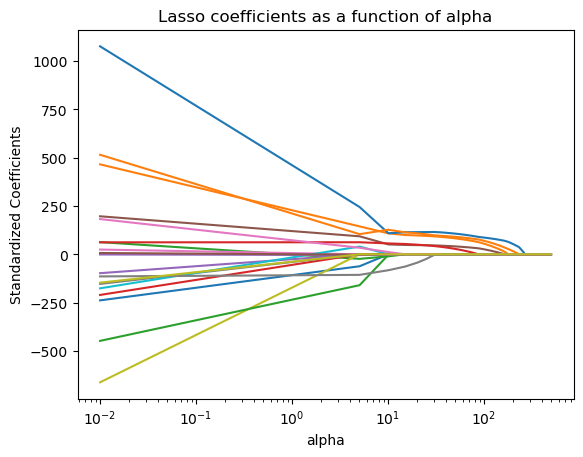

In [24]:
import numpy as np
import matplotlib.pyplot as plt

alphas = np.linspace(0.01,500,100)
lasso = Lasso(max_iter=10000)
coefs = []

for a in alphas:
    lasso.set_params(alpha=a)
    lasso.fit(X_train, y_train)
    coefs.append(lasso.coef_)

ax = plt.gca()

ax.plot(alphas, coefs)
ax.set_xscale('log')
plt.axis('tight')
plt.xlabel('alpha')
plt.ylabel('Standardized Coefficients')
plt.title('Lasso coefficients as a function of alpha');

But what is good $\alpha$ ?  We do cross validation. 

## Lasso with optimal alpha

To find the optimal value of alpha, we use scikit learns lasso linear model with iterative fitting along a regularization path (LassoCV). The best model is selected by cross-validation.

It uses grid search! 

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LassoCV.html#sklearn.linear_model.LassoCV.fit

In [25]:
from sklearn.linear_model import LassoCV

# Lasso with 5 fold cross-validation
model = LassoCV(cv=5, random_state=0, max_iter=10000, alphas=[0.1, 0.5, 1.0])

# Fit model
model.fit(X_train, y_train)

LassoCV(alphas=[0.1, 0.5, 1.0], cv=5, max_iter=10000, random_state=0)

the best one? 

In [26]:
model.alpha_

1.0

In [27]:
model

LassoCV(alphas=[0.1, 0.5, 1.0], cv=5, max_iter=10000, random_state=0)

In [28]:
from sklearn.linear_model import LassoCV

# Lasso with 5 fold cross-validation
model = LassoCV(cv=5, random_state=0, max_iter=10000)

# Fit model
model.fit(X_train, y_train)

LassoCV(cv=5, max_iter=10000, random_state=0)

In [29]:
model.alpha_

2.3441244939374593

In [30]:
model.alphas_   # alphas which tried

array([2.69517353e+02, 2.51352786e+02, 2.34412449e+02, 2.18613835e+02,
       2.03879994e+02, 1.90139165e+02, 1.77324421e+02, 1.65373349e+02,
       1.54227739e+02, 1.43833305e+02, 1.34139422e+02, 1.25098874e+02,
       1.16667628e+02, 1.08804621e+02, 1.01471553e+02, 9.46327104e+01,
       8.82547824e+01, 8.23067055e+01, 7.67595090e+01, 7.15861750e+01,
       6.67615064e+01, 6.22620043e+01, 5.80657536e+01, 5.41523161e+01,
       5.05026313e+01, 4.70989230e+01, 4.39246132e+01, 4.09642413e+01,
       3.82033885e+01, 3.56286080e+01, 3.32273590e+01, 3.09879463e+01,
       2.88994624e+01, 2.69517353e+01, 2.51352786e+01, 2.34412449e+01,
       2.18613835e+01, 2.03879994e+01, 1.90139165e+01, 1.77324421e+01,
       1.65373349e+01, 1.54227739e+01, 1.43833305e+01, 1.34139422e+01,
       1.25098874e+01, 1.16667628e+01, 1.08804621e+01, 1.01471553e+01,
       9.46327104e+00, 8.82547824e+00, 8.23067055e+00, 7.67595090e+00,
       7.15861750e+00, 6.67615064e+00, 6.22620043e+00, 5.80657536e+00,
      

# Try the best model! 

In [31]:
# Set best alpha
lasso_best = Lasso(alpha=model.alpha_)
lasso_best.fit(X_train, y_train)

Lasso(alpha=2.3441244939374593)

In [32]:
print(list(zip(lasso_best.coef_, X)))

[(-176.4530965705049, 'AtBat'), (271.23333276345295, 'Hits'), (-13.049492223041772, 'HmRun'), (-48.97878412496751, 'Runs'), (-13.836964370155378, 'RBI'), (140.12896436568263, 'Walks'), (-10.616534012349607, 'Years'), (-0.0, 'CAtBat'), (0.0, 'CHits'), (78.65781330867297, 'CHmRun'), (355.6618805642637, 'CRuns'), (60.505483348070484, 'CRBI'), (-262.751235240254, 'CWalks'), (65.61587416521279, 'PutOuts'), (-0.1450534249524432, 'Assists'), (-1.2293157493167375, 'Errors'), (99.66112742179929, 'League_N'), (-116.86405569164934, 'Division_W'), (-69.87497671182606, 'NewLeague_N')]


In [33]:
print('R squared training set', round(lasso_best.score(X_train, y_train), 2))
print('R squared test set', round(lasso_best.score(X_test, y_test), 2))

R squared training set 0.59
R squared test set 0.35


What about the error?

In [34]:
mean_squared_error(y_test, lasso_best.predict(X_test))

129468.59746480995

## Try Ridge 

## Try ElasticNet
Linear regression with combined L1 and L2 priors as regularizer.

Minimizes the objective function:


1 / (2 * n_samples) * ||y - Xw||^2_2 + alpha * l1_ratio * ||w||_1 + 0.5 * alpha * (1 - l1_ratio) * ||w||^2_2